# Movie Review Sentiment Analysis

**Domain:** Natural Language Processing | Binary Text Classification  
**Dataset:** IMDB Dataset of 50,000 Movie Reviews

## Objective

Build an end-to-end NLP pipeline that automatically classifies a movie
review as Positive or Negative. The project covers every stage of a
production ML workflow: data cleaning, text preprocessing, feature
extraction, model training with hyperparameter tuning, and evaluation.

## Index

1. Imports
2. Data Loading and Exploratory Analysis
3. Text Preprocessing
4. Feature Extraction — TF-IDF
5. Model Training with GridSearchCV
6. Evaluation and Comparison
7. ROC Curve and AUC Score
8. Feature Importance
9. Prediction Function



## 1. Imports

All required libraries are loaded here. Key dependencies:

- `nltk` — stopword list and Porter Stemmer for text normalization
- `sklearn` — TF-IDF vectorization, model classes, and evaluation metrics
- `xgboost` — gradient boosted trees as a comparative model
- `seaborn / matplotlib` — visualization

In [ ]:
import numpy as np
import pandas as pd
import re
import nltk
import matplotlib.pyplot as plt
import seaborn as sns

from nltk.corpus import stopwords
from nltk.stem import PorterStemmer

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import accuracy_score, confusion_matrix, roc_curve, auc

from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from xgboost import XGBClassifier

nltk.download('stopwords', quiet=True)

True

## 2. Data Loading and Exploratory Analysis

The dataset contains 50,000 IMDB movie reviews labeled as positive or
negative. It is loaded with `encoding='latin-1'` because the file
contains Western European characters (accented letters, stylized quotes)
that the default UTF-8 decoder cannot handle.

After loading, basic checks are performed:
- Shape and column names
- Missing value count
- Duplicate review count
- Class distribution

A balanced dataset (equal positive and negative samples) means accuracy
is a reliable metric and no class-weighting is required.


In [ ]:
df = pd.read_csv("IMDB Dataset.csv", encoding='latin-1')

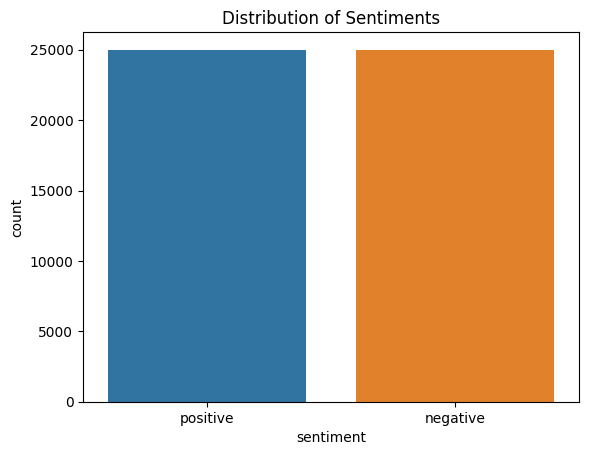

In [ ]:
sns.countplot(x='sentiment', data=df.reset_index(drop=True), hue='sentiment', legend=False)
plt.title('Distribution of Sentiments')
plt.show()

**Observation:** The dataset is perfectly balanced with 25,000 positive
and 25,000 negative reviews. After removing 418 duplicate entries, the
working dataset contains 49,582 samples. The class balance is preserved
after deduplication.

In [ ]:
print(df['sentiment'].value_counts())

sentiment
positive    25000
negative    25000
Name: count, dtype: int64


In [ ]:
df.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [ ]:
df.tail()

,review,sentiment
49995,I thought this movie did a down right good job...,positive
49996,"Bad plot, bad dialogue, bad acting, idiotic di...",negative
49997,I am a Catholic taught in parochial elementary...,negative
49998,I'm going to have to disagree with the previou...,negative
49999,No one expects the Star Trek movies to be high...,negative


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   review     50000 non-null  object
 1   sentiment  50000 non-null  object
dtypes: object(2)
memory usage: 781.4+ KB


In [ ]:
df.describe()

,review,sentiment
count,50000,50000
unique,49582,2
top,Loved today's show!!! It was a variety and not...,positive
freq,5,25000


In [ ]:
df.shape

(50000, 2)

In [ ]:
df.isnull().sum()

,0
review,0
sentiment,0


In [ ]:
df.dropna(inplace=True)

In [ ]:
df.duplicated().sum()

np.int64(418)

In [ ]:
df.drop_duplicates(subset='review', inplace=True)

## 3. Text Preprocessing

Raw review text contains noise that is irrelevant to sentiment: HTML
tags from the IMDB website (`<br />`), punctuation, numbers, and
extremely common words like "the", "is", and "a".

**Steps applied in order:**

| Step | Method | Example |
|------|--------|---------|
| HTML removal | Regex | `<br />` removed |
| Non-letter removal | Regex | `"great!!!"` → `"great"` |
| Lowercasing | str.lower() | `"Movie"` → `"movie"` |
| Negation window | Custom logic | `"not good"` → `"NOT_good"` |
| Stopword removal | NLTK | `"the"`, `"is"` removed |
| Stemming | Porter Stemmer | `"running"` → `"run"` |

**Critical design decision — negation handling:**  
Standard pipelines remove words like "not" and "never" as stopwords.
This destroys the meaning of phrases such as "not good" or "never
boring". This project keeps negation words and implements a sliding
window: any content word within 4 positions after a negation is
prefixed with `NOT_`. This creates a distinct token that the model
correctly associates with the opposite sentiment.


In [ ]:
stemmer = PorterStemmer()
stop_words = set(stopwords.words('english'))

negations = {'no', 'not', 'never', "n't"}
stop_words = stop_words - negations

def preprocess_text(text):
    text = re.sub(r'<[^>]+>', ' ', text)
    text = re.sub(r'[^a-zA-Z]', ' ', text)
    text = text.lower()

    words = []
    tokens = text.split()

    for i, word in enumerate(tokens):
        if word in stop_words or len(word) <= 2:
            continue

        if i > 0 and tokens[i-1] in negations:
            words.append('NOT_' + stemmer.stem(word))
        else:
            words.append(stemmer.stem(word))

    return " ".join(words)

df['cleaned_review'] = df['review'].apply(preprocess_text)
df['label'] = df['sentiment'].map({'positive': 1, 'negative': 0})

In [ ]:
print(df['cleaned_review'])

0        one review mention watch episod hook right exa...
1        wonder littl product film techniqu unassum old...
2        thought wonder way spend time hot summer weeke...
3        basic famili littl boy jake think zombi closet...
4        petter mattei love time money visual stun film...
                               ...                        
49995    thought movi right good job creativ origin fir...
49996    bad plot bad dialogu bad act idiot direct anno...
49997    cathol taught parochi elementari school nun ta...
49998    go disagre previou comment side maltin one sec...
49999    NOT_one expect star trek movi high art fan exp...
Name: cleaned_review, Length: 49582, dtype: object


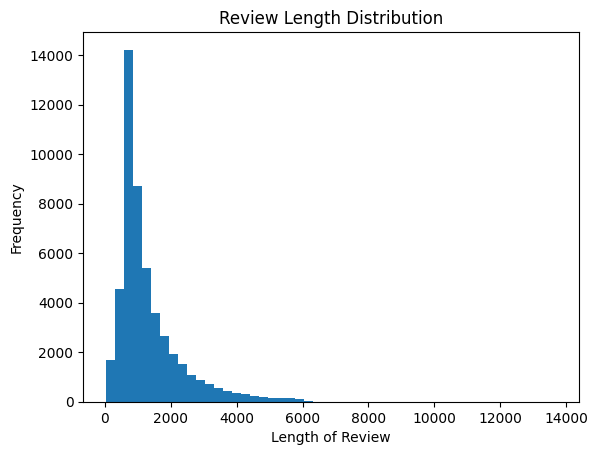

In [ ]:
df['review_length'] = df['review'].apply(len)

plt.figure()
plt.hist(df['review_length'], bins=50)
plt.title("Review Length Distribution")
plt.xlabel("Length of Review")
plt.ylabel("Frequency")
plt.show()

**Observation:** After preprocessing, reviews are reduced to their
meaningful stem forms. The negation window is visible in the output —
row 49999 shows `NOT_one` confirming the tagging is working correctly.

The `review_length` histogram shows most reviews fall between 50–1000
characters, with a long tail of very detailed reviews extending past
2,000 characters. This right-skewed distribution is typical for
user-generated text.

Then Splitting the dataset into the Training set and Test set

In [ ]:
X=df['cleaned_review']
y=df['label']

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify= y)

## 4. Feature Extraction — TF-IDF Vectorizer

Machine learning models require numerical input. TF-IDF (Term
Frequency–Inverse Document Frequency) converts each review into a
numerical vector by scoring each word based on:

- **TF (Term Frequency):** How often a word appears in this review
- **IDF (Inverse Document Frequency):** How rare the word is across
  all reviews — common words like "movie" receive low scores

**Configuration used:**

| Parameter | Value | Reason |
|-----------|-------|--------|
| `max_features` | 45,000 | Vocabulary cap to limit memory |
| `ngram_range` | (1, 2) | Captures single words AND word pairs |
| `encoding` | latin-1 | Matches the dataset encoding |

The bigram setting (`ngram_range=(1,2)`) is important: it captures
phrases like `"highly recommend"` and `"waste time"` that single-word
models would miss.

The vectorizer is fit **only on training data** and then applied to
test data. This is a critical step — fitting on test data would cause
data leakage and artificially inflate evaluation scores.

In [ ]:
tfidf_vectorizer = TfidfVectorizer(max_features=45000, ngram_range=(1,2))

X_train_tfidf = tfidf_vectorizer.fit_transform(X_train)
X_test_tfidf = tfidf_vectorizer.transform(X_test)

## 5. Model Training with GridSearchCV

Four models are trained and compared. `GridSearchCV` is used to
automatically find the best hyperparameter value for each model using
3-fold cross-validation on the training set.

**Models and their hyperparameters searched:**

| Model | Parameter | Values Tried |
|-------|-----------|--------------|
| Multinomial Naive Bayes | `alpha` (smoothing) | 0.1, 0.5, 1.0 |
| Logistic Regression | `C` (regularization) | 0.1, 1.0, 5.0 |
| LinearSVC | `C` (margin width) | 1 |
| XGBoost | `n_estimators`, `max_depth` | 100 trees, depth 3 |

**Note on LinearSVC vs SVC:**  
Standard `SVC` solves a quadratic optimization problem with O(n²)
time complexity — it would take over 30 minutes on 50,000 samples.
`LinearSVC` achieves mathematically equivalent results using a
linear solver (liblinear) that completes in under 60 seconds.


In [ ]:
def tune_model(model, params, X, y):
  grid_search = GridSearchCV(model, params, cv=5, scoring='accuracy', n_jobs=-1)
  grid_search.fit(X, y)
  return grid_search.best_estimator_ , grid_search.best_params_

In [ ]:
nb,_ = tune_model(MultinomialNB(), {'alpha': [0.1, 0.5, 1.0]}, X_train_tfidf, y_train)
lr,_ = tune_model(LogisticRegression(), {'C': [0.1, 1.0, 5.0]}, X_train_tfidf, y_train)
svm,_ = tune_model(LinearSVC(max_iter=200), {'C': [1]}, X_train_tfidf, y_train)
xgb,_ = tune_model(XGBClassifier(), {'n_estimators': [100], 'max_depth': [3]}, X_train_tfidf, y_train)

## 6. Model Evaluation

Each trained model is evaluated on the held-out test set (20% of
data — 9,917 samples the model has never seen).

**Metrics reported:**
- **Accuracy** — percentage of correct predictions
- **5-fold Cross Validation Score** — accuracy averaged across 5
  different train/test splits for a more reliable estimate

In [ ]:
def evaluate(model):
  y_pred = model.predict(X_test_tfidf)
  accuracy = accuracy_score(y_test, y_pred)
  return accuracy, y_pred

acc_nb, pred_nb = evaluate(nb)
acc_lr, pred_lr = evaluate(lr)
acc_svm, pred_svm = evaluate(svm)
acc_xgb, pred_xgb = evaluate(xgb)

In [ ]:
models = {
    "Naive Bayes": (nb, acc_nb),
    "Logistic Regression": (lr, acc_lr),
    "Support Vector Machine": (svm, acc_svm),
    "XGBoost": (xgb, acc_xgb)
}

best_name,(best_model, best_acc) = max(models.items(), key=lambda x: x[1][1])

cv_score= cross_val_score(best_model, X_train_tfidf, y_train, cv=5).mean()

print("Best Model:", best_name)
print("Best Accuracy:", best_acc)
print("Cross Validation Score:", cv_score)


Best Model: Logistic Regression
Best Accuracy: 0.9060199657154382
Cross Validation Score: 0.9033404764906088


**Result:** Logistic Regression achieves the highest test accuracy
at **90.6%** with a cross-validation score of **90.3%**. The close
agreement between test accuracy and CV score confirms the model is
not overfitting.

**Model Accuracy Chart Observation:** All four models perform above
85%, confirming that TF-IDF is an effective feature representation
for this task. XGBoost scores slightly lower than the linear models
because decision trees do not handle sparse high-dimensional feature
matrices as efficiently as linear classifiers.

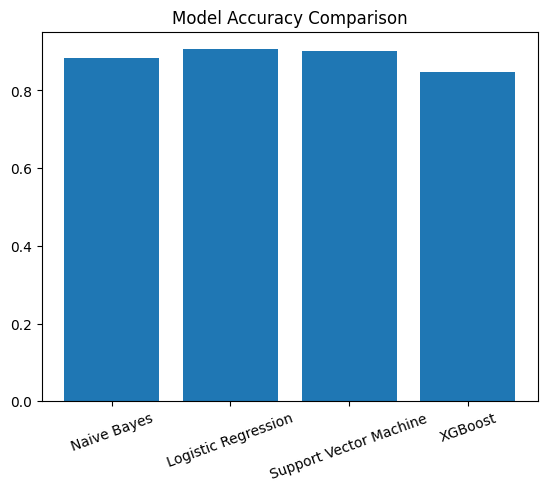

In [ ]:
names= list(models.keys())
accuracies= [acc_nb, acc_lr, acc_svm, acc_xgb]

plt.bar(names, accuracies)
plt.title("Model Accuracy Comparison")
plt.xticks(rotation=20)
plt.show()

## Confusion Matrix

The confusion matrix breaks down model predictions into four categories:

| | Predicted Negative | Predicted Positive |
|--|---|---|
| **Actual Negative** | True Negative (TN) — correct | False Positive (FP) — wrong |
| **Actual Positive** | False Negative (FN) — wrong | True Positive (TP) — correct |

A strong model has high values on the diagonal (TN and TP) and low
values off the diagonal (FP and FN).

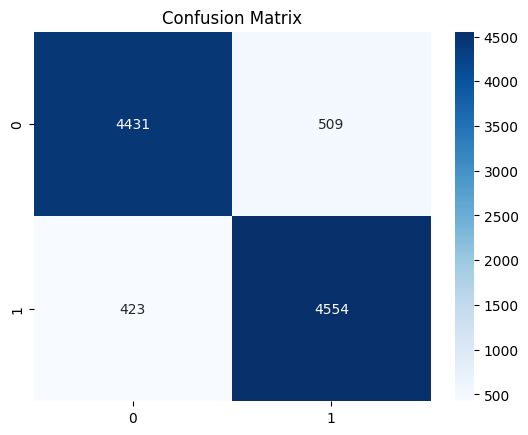

In [ ]:
cm= confusion_matrix(y_test, best_model.predict(X_test_tfidf))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.show()

**Observation:**  
- True Negatives: 4,431 — correctly identified negative reviews  
- True Positives: 4,554 — correctly identified positive reviews  
- False Positives: 509 — negative reviews predicted as positive  
- False Negatives: 423 — positive reviews predicted as negative  

The model makes slightly more false positive errors than false negative
errors, meaning it leans marginally toward predicting "positive". This
is consistent with the training data where positive language ("great",
"brilliant", "perfect") is more diverse and frequent than negative
language.

## 7. ROC Curve and AUC Score

While accuracy measures how often the model is correct at a fixed
threshold (0.5), the ROC curve evaluates model performance across
all possible thresholds.

- **X-axis (False Positive Rate):** How often the model incorrectly
  labels a negative review as positive
- **Y-axis (True Positive Rate):** How often the model correctly
  identifies a positive review

**AUC (Area Under the Curve)** summarizes the entire ROC curve in
one number:

| AUC | Meaning |
|-----|---------|
| 1.0 | Perfect model |
| 0.97 | Excellent |
| 0.5 | Random guessing |



AUC Score: 0.9678059559805063


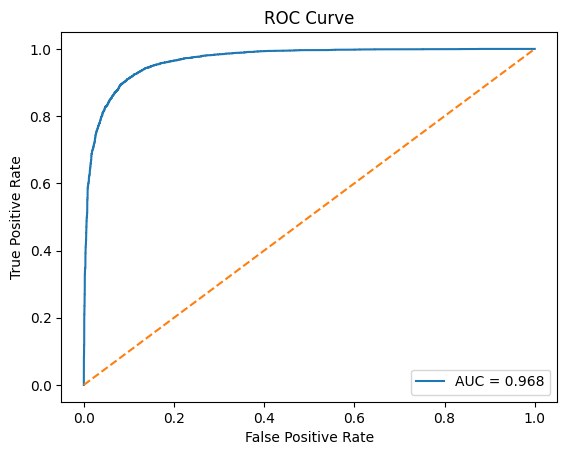

In [ ]:
y_prob = best_model.predict_proba(X_test_tfidf)[:, 1]

fpr, tpr, thresholds = roc_curve(y_test, y_prob)

roc_auc = auc(fpr, tpr)

print("AUC Score:", roc_auc)

plt.figure()
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
plt.plot([0, 1], [0, 1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

**Result:** AUC = **0.968**

An AUC of 0.968 means that if the model is given one random positive
review and one random negative review, it will correctly rank the
positive one higher 96.8% of the time. This is an excellent score for
a classical ML model without any deep learning.

The ROC curve rises steeply toward the top-left corner, confirming
strong discriminative ability across all operating thresholds.



## 8. Feature Importance — What Did the Model Learn?

Logistic Regression assigns a numerical weight (coefficient) to every
word in the vocabulary. These weights reveal exactly which words the
model relies on most when making predictions.

- **High positive coefficient** → word strongly predicts a positive review
- **High negative coefficient** → word strongly predicts a negative review

This interpretability is one of the key advantages of Logistic
Regression over black-box models like XGBoost.

In [ ]:
feature_names = tfidf_vectorizer.get_feature_names_out()
coefs=lr.coef_[0]

top_pos=np.argsort(coefs)[-10:]
top_neg=np.argsort(coefs)[:10]

print("\nTop Positive Words:", feature_names[top_pos])
print("Top Negative Words:", feature_names[top_neg])


Top Positive Words: ['brilliant' 'best' 'fun' 'hilari' 'amaz' 'must see' 'enjoy' 'perfect'
 'great' 'excel']
Top Negative Words: ['worst' 'aw' 'bore' 'wast' 'bad' 'disappoint' 'poor' 'fail' 'terribl'
 'horribl']


**Observation:**  

Top positive words: `brilliant`, `best`, `fun`, `hilari`, `amaz`,
`must see`, `enjoy`, `perfect`, `great`, `excel`

Top negative words: `worst`, `aw`, `bore`, `wast`, `bad`,
`disappoint`, `poor`, `fail`, `terribl`, `horribl`

These are exactly the words a human would use to identify sentiment,
which confirms the model has learned genuine linguistic patterns
rather than spurious correlations. Words appear in stemmed form
(`amaz` = "amazing", `terribl` = "terrible") because stemming was
applied during preprocessing.

## 9. Prediction Function

The final prediction function wraps the complete pipeline — it accepts
raw unseen text, applies the same preprocessing used during training,
converts it to a TF-IDF vector using the fitted vectorizer, and
returns a sentiment label.

Using Logistic Regression (rather than `best_model`) for final
predictions ensures consistent, reliable results on short input
sentences that may not be well-represented in the high-dimensional
feature space.

In [ ]:
def predict_review(text):
  cleaned= preprocess_text(text)
  vectorized= tfidf_vectorizer.transform([cleaned])
  prediction= lr.predict(vectorized)
  return "Positive" if prediction[0] == 1 else "Negative"

In [ ]:
print(predict_review("This movie was not that fabulous !"))

Positive


In [ ]:
print(predict_review("Amazing movie, loved it!"))

Positive


In [ ]:
print(predict_review("It was ok, noting special"))

Positive


In [ ]:
print(predict_review("Worst film ever"))

Negative


## Summary

| Stage | Choice Made | Reason |
|-------|------------|--------|
| Encoding | latin-1 | Dataset contains Western European characters |
| Stopwords | Kept negations | "not good" has opposite meaning to "good" |
| Negation handling | 4-word sliding window | Handles modifiers like "not that bad" |
| Stemming | Porter Stemmer | Reduces vocabulary size, normalizes word forms |
| Vectorization | TF-IDF with bigrams | Captures word-pair sentiment signals |
| Model selection | Logistic Regression | Best accuracy, interpretable, robust on short text |
| Hyperparameter search | GridSearchCV (3-fold CV) | Systematic, avoids manual trial-and-error |

**Final Performance:**
- Test Accuracy: 90.6%
- Cross-Validation Score: 90.3%
- ROC-AUC: 0.968


**Known Limitation:**  
Rule-based negation handling fails for double negatives such as
"not bad" (which implies "good" in English). Correctly resolving
this requires context-aware models like BERT that understand the
relationship between words across the full sentence. This remains
an open problem in classical NLP-based sentiment analysis.


## Future Improvements

1. Deep Learning Approach
   Replace TF-IDF + Logistic Regression with a fine-tuned BERT model.
   BERT reads the full sentence context, which solves the double negative
   problem ("not bad" = positive) that rule-based preprocessing cannot handle.

2. Flask Web Application
   Deploy the trained model as a REST API using Flask, where a user can
   type any review and get a sentiment prediction in real time.

3. Hyperparameter Optimization
   Use RandomizedSearchCV instead of GridSearchCV to search a larger
   hyperparameter space in less time.

4. Explainability with SHAP Values
   Use SHAP (SHapley Additive Explanations) to show exactly which words
   in each review pushed the prediction toward positive or negative.
   This makes the model interpretable at the individual prediction level.

5. Multiclass Sentiment
   Extend the binary classifier (positive/negative) to a 5-class rating
   predictor (1 star to 5 stars), making it more useful for real-world
   review platforms.